# Trabalho Final - notebook base do projeto da Kaylanne

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **Quais características (hipertensão, idade, doença cardíaca, glicose, status de fumante, IMC) são mais comuns entre as pessoas que sofreram AVC?**

(hipertensão, idade, doença cardíaca, glicose, status de fumante, IMC)

--- O Acidente Vascular Cerebral (AVC) é uma das principais causas de morte e incapacidade no mundo, e boa parte dos seus fatores de risco já são bem documentados na literatura médica (idade avançada, hipertensão, doença cardíaca, glicose elevada, entre outros). Neste trabalho será utilizado o conjunto de dados *Healthcare Dataset Stroke Data*, que reúne informações de saúde e estilo de vida de 5.110 pessoas, incluindo se cada uma sofreu ou não um AVC. Pretende-se avaliar, dentro desta amostra, se a proporção de pessoas que sofreram AVC de fato varia entre os grupos de hipertensão, idade, doença cardíaca, nível de glicose, status de fumante e IMC — sem presumir de antemão que todas essas características terão a mesma força de associação, já que algumas delas podem estar confundidas entre si (por exemplo, idade e status de fumante, como será mostrado adiante).

In [2]:
# Le o dataset de AVC (cada linha e uma pessoa) e mostra as primeiras linhas
# para uma primeira olhada nas colunas disponiveis
df = pd.read_csv("../datasets/kaylanne/healthcare-dataset-stroke-data.zip", compression='zip')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# Lista todas as colunas do dataset
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

## Classificação das variáveis associadas à pergunta de pesquisa

In [4]:
# hipertensao: verifica os valores possiveis
df["hypertension"].unique()

array([0, 1])

A hipertensão (`hypertension`) é uma variável **categórica binária**: 0 = pessoa não tem hipertensão, 1 = pessoa tem hipertensão. Possui 2 categorias.

In [5]:
# idade: verifica os valores possiveis
df["age"].unique()

array([6.70e+01, 6.10e+01, 8.00e+01, 4.90e+01, 7.90e+01, 8.10e+01,
       7.40e+01, 6.90e+01, 5.90e+01, 7.80e+01, 5.40e+01, 5.00e+01,
       6.40e+01, 7.50e+01, 6.00e+01, 5.70e+01, 7.10e+01, 5.20e+01,
       8.20e+01, 6.50e+01, 5.80e+01, 4.20e+01, 4.80e+01, 7.20e+01,
       6.30e+01, 7.60e+01, 3.90e+01, 7.70e+01, 7.30e+01, 5.60e+01,
       4.50e+01, 7.00e+01, 6.60e+01, 5.10e+01, 4.30e+01, 6.80e+01,
       4.70e+01, 5.30e+01, 3.80e+01, 5.50e+01, 1.32e+00, 4.60e+01,
       3.20e+01, 1.40e+01, 3.00e+00, 8.00e+00, 3.70e+01, 4.00e+01,
       3.50e+01, 2.00e+01, 4.40e+01, 2.50e+01, 2.70e+01, 2.30e+01,
       1.70e+01, 1.30e+01, 4.00e+00, 1.60e+01, 2.20e+01, 3.00e+01,
       2.90e+01, 1.10e+01, 2.10e+01, 1.80e+01, 3.30e+01, 2.40e+01,
       3.40e+01, 3.60e+01, 6.40e-01, 4.10e+01, 8.80e-01, 5.00e+00,
       2.60e+01, 3.10e+01, 7.00e+00, 1.20e+01, 6.20e+01, 2.00e+00,
       9.00e+00, 1.50e+01, 2.80e+01, 1.00e+01, 1.80e+00, 3.20e-01,
       1.08e+00, 1.90e+01, 6.00e+00, 1.16e+00, 1.00e+00, 1.40e

A idade (`age`) é uma variável **numérica** e varia de 0.08 a 82.0 anos no dataset (o valor 0.08 corresponde a um bebê de menos de 1 mês, já que o dataset inclui crianças — há inclusive a categoria "children" na coluna de ocupação, não usada nesta pergunta).

In [6]:
# doenca cardiaca: verifica os valores possiveis
df["heart_disease"].unique()

array([1, 0])

A doença cardíaca (`heart_disease`) é uma variável **categórica binária**: 0 = pessoa não tem doença cardíaca, 1 = pessoa tem doença cardíaca. Possui 2 categorias.

In [7]:
# glicose: verifica os valores possiveis (variavel continua, por isso o array e resumido)
df["avg_glucose_level"].unique()

array([228.69, 202.21, 105.92, ...,  82.99, 166.29,  85.28], shape=(3979,))

O nível médio de glicose (`avg_glucose_level`) é uma variável **numérica** e varia de 55.12 a 271.74 mg/dL no dataset. O arquivo não documenta se a medição foi feita em jejum ou não; isso será retomado como hipótese na seção de estatística descritiva.

In [8]:
# status de fumante: verifica os valores possiveis
df["smoking_status"].unique()

<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

O status de fumante (`smoking_status`) é uma variável **categórica** com 4 categorias: "formerly smoked" (ex-fumante), "never smoked" (nunca fumou), "smokes" (fuma) e "Unknown" (não informado). É importante notar desde já que "Unknown" **não é um dado faltante** (não é `NaN`) — é uma categoria válida do questionário original, que será investigada mais adiante.

In [9]:
# IMC: verifica os valores possiveis (inclui valores faltantes reais, tratados na limpeza)
df["bmi"].unique()

array([36.6,  nan, 32.5, 34.4, 24. , 29. , 27.4, 22.8, 24.2, 29.7, 36.8,
       27.3, 28.2, 30.9, 37.5, 25.8, 37.8, 22.4, 48.9, 26.6, 27.2, 23.5,
       28.3, 44.2, 25.4, 22.2, 30.5, 26.5, 33.7, 23.1, 32. , 29.9, 23.9,
       28.5, 26.4, 20.2, 33.6, 38.6, 39.2, 27.7, 31.4, 36.5, 33.2, 32.8,
       40.4, 25.3, 30.2, 47.5, 20.3, 30. , 28.9, 28.1, 31.1, 21.7, 27. ,
       24.1, 45.9, 44.1, 22.9, 29.1, 32.3, 41.1, 25.6, 29.8, 26.3, 26.2,
       29.4, 24.4, 28. , 28.8, 34.6, 19.4, 30.3, 41.5, 22.6, 56.6, 27.1,
       31.3, 31. , 31.7, 35.8, 28.4, 20.1, 26.7, 38.7, 34.9, 25. , 23.8,
       21.8, 27.5, 24.6, 32.9, 26.1, 31.9, 34.1, 36.9, 37.3, 45.7, 34.2,
       23.6, 22.3, 37.1, 45. , 25.5, 30.8, 37.4, 34.5, 27.9, 29.5, 46. ,
       42.5, 35.5, 26.9, 45.5, 31.5, 33. , 23.4, 30.7, 20.5, 21.5, 40. ,
       28.6, 42.2, 29.6, 35.4, 16.9, 26.8, 39.3, 32.6, 35.9, 21.2, 42.4,
       40.5, 36.7, 29.3, 19.6, 18. , 17.6, 19.1, 50.1, 17.7, 54.6, 35. ,
       22. , 39.4, 19.7, 22.5, 25.2, 41.8, 60.9, 23

O IMC (`bmi`) é uma variável **numérica** e varia de 10.3 a 97.6 no dataset. Diferente das demais variáveis da pergunta, o IMC tem valores realmente faltantes (`NaN`), como aparece no array acima — isso será quantificado e tratado nas próximas duas seções.

## Verificando a qualidade dos dados

In [10]:
# Verifica se ha linhas inteiramente duplicadas
df.duplicated().sum()

np.int64(0)

In [11]:
# Se houver duplicatas, mostra quais sao
df[df.duplicated()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


**Conclusão 1:** não há linhas duplicadas no dataset analisado.

In [12]:
# Verifica a quantidade e o percentual de valores faltantes (NaN) por coluna
dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
id,0,0.000000
gender,0,0.000000
age,0,0.000000
hypertension,0,0.000000
heart_disease,0,0.000000
ever_married,0,0.000000
work_type,0,0.000000
Residence_type,0,0.000000
avg_glucose_level,0,0.000000
bmi,201,3.933464


**Conclusão 2:** a única coluna com valores realmente faltantes (`NaN`) é `bmi`, com 201 valores faltantes (3.93% das 5.110 linhas). Nenhuma outra coluna usada na pergunta de pesquisa tem dado faltante — em particular, `smoking_status` não tem nenhum `NaN`: a categoria "Unknown" que aparece nela é uma resposta válida do questionário (provavelmente "não informado" ou "não perguntado", como será visto na seção de estatística descritiva), não um erro de coleta, e por isso não deve ser tratada como dado faltante nem removida na limpeza.

## Limpeza do conjunto de dados

In [13]:
# Se houver duplicatas, remove a linha inteira que estiver duplicada
# (aqui nao ha nenhuma, mas o passo fica documentado por consistencia)
df = df.drop_duplicates()

In [14]:
# bmi tem 201 valores faltantes reais (3.93% do dataset). Optamos por REMOVER essas linhas
# em vez de imputar (ex: preencher com a media/mediana), por dois motivos:
# 1) a fracao de linhas afetada e pequena (3.93%), entao a perda de amostra e pequena;
# 2) o IMC e usado mais adiante para formar faixas (Abaixo do peso / Normal / Sobrepeso / Obesidade)
#    que servem de categoria de analise - imputar um valor artificial decidiria "na marra" em qual
#    faixa cada pessoa cai, o que contaminaria justamente a comparacao que queremos fazer

print("Linhas antes de remover bmi faltante:", df.shape[0])
print("Valores faltantes em bmi antes:", df["bmi"].isnull().sum())

df = df.dropna(subset=["bmi"])

print("\nLinhas depois de remover bmi faltante:", df.shape[0])
print("Valores faltantes em bmi depois:", df["bmi"].isnull().sum())

Linhas antes de remover bmi faltante: 5110
Valores faltantes em bmi antes: 201

Linhas depois de remover bmi faltante: 4909
Valores faltantes em bmi depois: 0


**Conclusão 3:** não havia duplicatas para remover. Para o IMC, optamos por remover as 201 linhas (3.93%) com `bmi` faltante em vez de imputar um valor, porque o IMC será usado logo abaixo para formar faixas de análise (Abaixo do peso / Peso normal / Sobrepeso / Obesidade) — imputar arbitrariamente colocaria pessoas em uma faixa "de mentira" e comprometeria justamente essa comparação. O dataset ficou com 4.909 linhas (de 5.110 originais). Nenhuma outra limpeza foi necessária: como visto na Conclusão 2, "Unknown" em `smoking_status` é uma categoria válida (não um dado faltante), então não foi removida nem alterada.

## Estatística descritiva

Para cada uma das características da pergunta de pesquisa, calculamos a **proporção de pessoas que sofreram AVC** (`stroke`) dentro de cada categoria/faixa daquela característica — isso responde diretamente à pergunta "quais características são mais comuns entre quem sofreu AVC": quanto maior a taxa de AVC em uma faixa, mais aquela faixa está associada a ter sofrido um AVC nesta amostra. Como `stroke` é uma coluna 0/1, a média de `stroke` dentro de um grupo é exatamente a proporção de pessoas daquele grupo que sofreram AVC.

In [15]:
# Esta celula cria faixas (variaveis categoricas) a partir de "age", que e numerica,
# para poder comparar grupos de pessoas com groupby() nas celulas seguintes
#
# Usamos a classificacao de faixa etaria do CDC/BRFSS (Behavioral Risk Factor Surveillance
# System), que e o proprio orgao que reporta prevalencia de AVC por faixa etaria nos EUA:
# 18-44, 45-64 e 65+ anos (CDC MMWR, "Prevalence of Stroke - BRFSS, United States, 2011-2022").
# Como o dataset tambem inclui criancas (idade minima de 0.08 ano), adicionamos uma faixa
# extra "<18" que a classificacao do CDC (feita so com adultos) nao cobre

df["Faixa Etaria"], cortes_idade = pd.cut(df["age"], bins=[0, 18, 45, 65, 150],
                                          labels=["<18 (menor de idade)", "18-44", "45-64", "65+"],
                                          retbins=True)

# Mostra os cortes usados e quantas pessoas caem em cada faixa
print("Cortes das faixas etarias (anos):", cortes_idade)
print("\nPessoas por faixa etaria:")
print(df["Faixa Etaria"].value_counts())

Cortes das faixas etarias (anos): [  0  18  45  65 150]

Pessoas por faixa etaria:
Faixa Etaria
18-44                   1652
45-64                   1469
<18 (menor de idade)     895
65+                      893
Name: count, dtype: int64


In [16]:
# Esta celula cria faixas a partir de "avg_glucose_level", que e numerica
#
# Usamos os limiares de glicose de jejum da American Diabetes Association (ADA, Standards
# of Care in Diabetes): Normal < 100 mg/dL, Pre-diabetes 100-125 mg/dL, Diabetes >= 126 mg/dL.
# HIPOTESE: o dataset nao documenta se "avg_glucose_level" foi medido em jejum - os dados
# reais mostram apenas o valor em mg/dL (55.12 a 271.74). Aplicamos o limiar de jejum da ADA
# porque e a classificacao de glicose mais usada e reconhecida, mas o resultado deve ser lido
# como aproximacao, nao como diagnostico real de diabetes

df["Faixa Glicose"], cortes_glicose = pd.cut(df["avg_glucose_level"], bins=[0, 100, 126, 1000],
                                             labels=["Normal (<100)", "Pre-diabetes (100-125)", "Diabetes (>=126)"],
                                             retbins=True)

print("Cortes das faixas de glicose (mg/dL):", cortes_glicose)
print("\nPessoas por faixa de glicose:")
print(df["Faixa Glicose"].value_counts())

Cortes das faixas de glicose (mg/dL): [   0  100  126 1000]

Pessoas por faixa de glicose:
Faixa Glicose
Normal (<100)             3030
Pre-diabetes (100-125)     964
Diabetes (>=126)           915
Name: count, dtype: int64


In [17]:
# Esta celula cria faixas a partir de "bmi", que e numerica
#
# Usamos a classificacao oficial de IMC da OMS (WHO): Abaixo do peso < 18.5, Peso normal
# 18.5-24.9, Sobrepeso 25-29.9, Obesidade >= 30 (kg/m2)

df["Faixa IMC"], cortes_imc = pd.cut(df["bmi"], bins=[0, 18.5, 25, 30, 1000],
                                     labels=["Abaixo do peso (<18.5)", "Peso normal (18.5-24.9)",
                                             "Sobrepeso (25-29.9)", "Obesidade (>=30)"],
                                     retbins=True)

print("Cortes das faixas de IMC:", cortes_imc)
print("\nPessoas por faixa de IMC:")
print(df["Faixa IMC"].value_counts())

Cortes das faixas de IMC: [   0.    18.5   25.    30.  1000. ]

Pessoas por faixa de IMC:
Faixa IMC
Obesidade (>=30)           1893
Sobrepeso (25-29.9)        1409
Peso normal (18.5-24.9)    1258
Abaixo do peso (<18.5)      349
Name: count, dtype: int64


In [18]:
# Taxa de AVC (proporcao de stroke=1) por status de hipertensao
df_tx_hipertensao = df.groupby("hypertension")[["stroke"]].mean()

print("Taxa de AVC por hipertensao (0=nao tem, 1=tem):")
print(df_tx_hipertensao)

print("\n################################\n")

print("Maior taxa de AVC encontrada:")
print(df_tx_hipertensao.max())
print("\nGrupo de hipertensao correspondente a maior taxa de AVC:")
print(df_tx_hipertensao.idxmax())

Taxa de AVC por hipertensao (0=nao tem, 1=tem):
                stroke
hypertension          
0             0.033423
1             0.133038

################################

Maior taxa de AVC encontrada:
stroke    0.133038
dtype: float64

Grupo de hipertensao correspondente a maior taxa de AVC:
stroke    1
dtype: int64


**Conclusão 4:** pessoas com hipertensão têm uma taxa de AVC de 13.30%, cerca de 4 vezes maior que a taxa de 3.34% entre quem não tem hipertensão. A hipertensão está claramente associada a uma proporção maior de AVC nesta amostra.

In [19]:
# Taxa de AVC por faixa etaria
df_tx_idade = df.groupby("Faixa Etaria", observed=True)[["stroke"]].mean()

print("Taxa de AVC por faixa etaria:")
print(df_tx_idade)

print("\n################################\n")

print("Maior taxa de AVC encontrada:")
print(df_tx_idade.max())
print("\nFaixa etaria correspondente a maior taxa de AVC:")
print(df_tx_idade.idxmax())

print("\n################################\n")

print("Menor taxa de AVC encontrada:")
print(df_tx_idade.min())
print("\nFaixa etaria correspondente a menor taxa de AVC:")
print(df_tx_idade.idxmin())

Taxa de AVC por faixa etaria:
                        stroke
Faixa Etaria                  
<18 (menor de idade)  0.001117
18-44                 0.006053
45-64                 0.045609
65+                   0.146697

################################

Maior taxa de AVC encontrada:
stroke    0.146697
dtype: float64

Faixa etaria correspondente a maior taxa de AVC:
stroke    65+
dtype: category
Categories (4, str): ['<18 (menor de idade)' < '18-44' < '45-64' < '65+']

################################

Menor taxa de AVC encontrada:
stroke    0.001117
dtype: float64

Faixa etaria correspondente a menor taxa de AVC:
stroke    <18 (menor de idade)
dtype: category
Categories (4, str): ['<18 (menor de idade)' < '18-44' < '45-64' < '65+']


**Conclusão 5:** a idade é o fator com a relação mais clara e monotônica com o AVC nesta amostra: a taxa sobe de 0.11% em menores de 18 anos, para 0.61% (18-44), 4.56% (45-64) e chega a 14.67% em pessoas com 65 anos ou mais — cerca de 130 vezes maior que a faixa mais jovem. Isso é consistente com a literatura, que aponta a idade avançada como um dos principais fatores de risco de AVC.

In [20]:
# Taxa de AVC por status de doenca cardiaca
df_tx_cardiaca = df.groupby("heart_disease")[["stroke"]].mean()

print("Taxa de AVC por doenca cardiaca (0=nao tem, 1=tem):")
print(df_tx_cardiaca)

print("\n################################\n")

print("Maior taxa de AVC encontrada:")
print(df_tx_cardiaca.max())
print("\nGrupo de doenca cardiaca correspondente a maior taxa de AVC:")
print(df_tx_cardiaca.idxmax())

Taxa de AVC por doenca cardiaca (0=nao tem, 1=tem):
                 stroke
heart_disease          
0              0.036219
1              0.164609

################################

Maior taxa de AVC encontrada:
stroke    0.164609
dtype: float64

Grupo de doenca cardiaca correspondente a maior taxa de AVC:
stroke    1
dtype: int64


**Conclusão 6:** pessoas com doença cardíaca têm taxa de AVC de 16.46%, cerca de 4.5 vezes maior que a taxa de 3.62% entre quem não tem doença cardíaca — a maior diferença relativa entre grupos observada até aqui.

In [21]:
# Taxa de AVC por faixa de glicose
df_tx_glicose = df.groupby("Faixa Glicose", observed=True)[["stroke"]].mean()

print("Taxa de AVC por faixa de glicose:")
print(df_tx_glicose)

print("\n################################\n")

print("Maior taxa de AVC encontrada:")
print(df_tx_glicose.max())
print("\nFaixa de glicose correspondente a maior taxa de AVC:")
print(df_tx_glicose.idxmax())

Taxa de AVC por faixa de glicose:
                          stroke
Faixa Glicose                   
Normal (<100)           0.030693
Pre-diabetes (100-125)  0.030083
Diabetes (>=126)        0.095082

################################

Maior taxa de AVC encontrada:
stroke    0.095082
dtype: float64

Faixa de glicose correspondente a maior taxa de AVC:
stroke    Diabetes (>=126)
dtype: category
Categories (3, str): ['Normal (<100)' < 'Pre-diabetes (100-125)' < 'Diabetes (>=126)']


**Conclusão 7:** a taxa de AVC é de 9.51% na faixa "Diabetes" (glicose >= 126 mg/dL), cerca de 3 vezes maior que nas faixas "Normal" (3.07%) e "Pre-diabetes" (3.01%) — essas duas últimas praticamente empatadas. Ou seja, nesta amostra a associação com AVC aparece concentrada na faixa mais alta de glicose, e não de forma gradual entre as três faixas.

In [22]:
# Taxa de AVC por status de fumante
df_tx_fumo = df.groupby("smoking_status")[["stroke"]].mean()

print("Taxa de AVC por status de fumante:")
print(df_tx_fumo)

print("\n################################\n")

print("Maior taxa de AVC encontrada:")
print(df_tx_fumo.max())
print("\nStatus de fumante correspondente a maior taxa de AVC:")
print(df_tx_fumo.idxmax())

print("\n################################\n")

print("Menor taxa de AVC encontrada:")
print(df_tx_fumo.min())
print("\nStatus de fumante correspondente a menor taxa de AVC:")
print(df_tx_fumo.idxmin())

Taxa de AVC por status de fumante:
                   stroke
smoking_status           
Unknown          0.019555
formerly smoked  0.068100
never smoked     0.045356
smokes           0.052917

################################

Maior taxa de AVC encontrada:
stroke    0.0681
dtype: float64

Status de fumante correspondente a maior taxa de AVC:
stroke    formerly smoked
dtype: str

################################

Menor taxa de AVC encontrada:
stroke    0.019555
dtype: float64

Status de fumante correspondente a menor taxa de AVC:
stroke    Unknown
dtype: str


In [23]:
# O grupo "Unknown" tem a MENOR taxa de AVC de todas as categorias de status de fumante,
# o que e contraintuitivo (nao ha motivo obvio para "nao informar o status de fumante"
# proteger contra AVC). Antes de concluir qualquer coisa, investigamos quem compoe esse grupo,
# comparando a idade media dele com a dos demais e cruzando com a faixa etaria

print("Idade media no grupo Unknown:", df[df["smoking_status"] == "Unknown"]["age"].mean())
print("Idade media nos demais grupos:", df[df["smoking_status"] != "Unknown"]["age"].mean())

print("\nCruzamento entre faixa etaria e status de fumante (contagem de pessoas):")
print(pd.crosstab(df["Faixa Etaria"], df["smoking_status"]))

Idade media no grupo Unknown: 29.511207012811866
Idade media nos demais grupos: 48.645942790426155

Cruzamento entre faixa etaria e status de fumante (contagem de pessoas):
smoking_status        Unknown  formerly smoked  never smoked  smokes
Faixa Etaria                                                        
<18 (menor de idade)      693               26           163      13
18-44                     362              215           743     332
45-64                     272              330           577     290
65+                       156              266           369     102


**Conclusão 8:** o status de fumante "Unknown" tem a menor taxa de AVC (1.96%), abaixo até de "never smoked" (4.54%), enquanto "formerly smoked" tem a maior (6.81%) e "smokes" fica em 5.29%. Investigando o grupo "Unknown", ele é bem mais jovem (idade média de 29.51 anos) que os demais grupos somados (idade média de 48.65 anos): 693 das 895 pessoas menores de 18 anos (77.43%) estão na categoria "Unknown", e essas 693 pessoas representam 46.73% de todo o grupo "Unknown". Como a Conclusão 5 já mostrou que quase ninguém sofre AVC antes dos 18 anos, a baixa taxa de AVC do grupo "Unknown" é, em boa parte, um **confundidor de idade** (crianças/adolescentes cujo status de fumante nunca foi perguntado), não um efeito real de "não informar o status de fumante". Já a comparação entre "formerly smoked", "never smoked" e "smokes" é mais confiável, e ali quem já fumou no passado aparece com a maior taxa de AVC.

In [24]:
# Taxa de AVC por faixa de IMC
df_tx_imc = df.groupby("Faixa IMC", observed=True)[["stroke"]].mean()

print("Taxa de AVC por faixa de IMC:")
print(df_tx_imc)

print("\n################################\n")

print("Maior taxa de AVC encontrada:")
print(df_tx_imc.max())
print("\nFaixa de IMC correspondente a maior taxa de AVC:")
print(df_tx_imc.idxmax())

print("\n################################\n")

print("Menor taxa de AVC encontrada:")
print(df_tx_imc.min())
print("\nFaixa de IMC correspondente a menor taxa de AVC:")
print(df_tx_imc.idxmin())

Taxa de AVC por faixa de IMC:
                           stroke
Faixa IMC                        
Abaixo do peso (<18.5)   0.002865
Peso normal (18.5-24.9)  0.029412
Sobrepeso (25-29.9)      0.053229
Obesidade (>=30)         0.050713

################################

Maior taxa de AVC encontrada:
stroke    0.053229
dtype: float64

Faixa de IMC correspondente a maior taxa de AVC:
stroke    Sobrepeso (25-29.9)
dtype: category
Categories (4, str): ['Abaixo do peso (<18.5)' < 'Peso normal (18.5-24.9)' < 'Sobrepeso (25-29.9)' < 'Obesidade (>=30)']

################################

Menor taxa de AVC encontrada:
stroke    0.002865
dtype: float64

Faixa de IMC correspondente a menor taxa de AVC:
stroke    Abaixo do peso (<18.5)
dtype: category
Categories (4, str): ['Abaixo do peso (<18.5)' < 'Peso normal (18.5-24.9)' < 'Sobrepeso (25-29.9)' < 'Obesidade (>=30)']


In [25]:
# A faixa "Abaixo do peso" tem a MENOR taxa de AVC de todas as faixas de IMC, o que tambem
# e contraintuitivo, ja que baixo peso costuma ser associado a pior saude, nao a melhor.
# Investigamos a idade media desse grupo, do mesmo jeito que fizemos com o "Unknown" de fumante

print("Idade media no grupo Abaixo do peso:", df[df["Faixa IMC"] == "Abaixo do peso (<18.5)"]["age"].mean())
print("Idade media nas demais faixas de IMC:", df[df["Faixa IMC"] != "Abaixo do peso (<18.5)"]["age"].mean())

print("\nCruzamento entre faixa etaria e faixa de IMC (contagem de pessoas):")
print(pd.crosstab(df["Faixa Etaria"], df["Faixa IMC"]))

Idade media no grupo Abaixo do peso:

 10.875988538681948
Idade media nas demais faixas de IMC: 45.31368421052631

Cruzamento entre faixa etaria e faixa de IMC (contagem de pessoas):
Faixa IMC             Abaixo do peso (<18.5)  Peso normal (18.5-24.9)  \
Faixa Etaria                                                            
<18 (menor de idade)                     311                      405   
18-44                                     16                      455   
45-64                                      9                      225   
65+                                       13                      173   

Faixa IMC             Sobrepeso (25-29.9)  Obesidade (>=30)  
Faixa Etaria                                                 
<18 (menor de idade)                   96                83  
18-44                                 496               685  
45-64                                 475               760  
65+                                   342               365  


**Conclusão 9:** a faixa "Abaixo do peso" tem a menor taxa de AVC (0.29%), bem abaixo de "Peso normal" (2.94%), "Obesidade" (5.07%) e "Sobrepeso", que tem a maior taxa (5.32%). Investigando o grupo "Abaixo do peso", a idade média nele é de apenas 10.88 anos, contra 45.31 anos nas demais faixas de IMC: 311 das 349 pessoas nessa faixa (89.11%) são menores de 18 anos. Ou seja, assim como no status de fumante, a baixa taxa de AVC do grupo "Abaixo do peso" é majoritariamente um **confundidor de idade** — o grupo é dominado por crianças, que quase não sofrem AVC nesta amostra, e não evidência de que baixo peso protege contra AVC. Já a comparação entre "Peso normal", "Sobrepeso" e "Obesidade" (faixas onde adultos predominam) mostra que excesso de peso está associado a taxa de AVC maior que peso normal.

**Conclusão final (síntese):** juntando as seis características da pergunta de pesquisa, todas aparecem associadas a uma taxa de AVC mais alta em pelo menos um dos seus grupos/faixas, mas com força e confiabilidade diferentes. Idade é o fator mais forte e mais confiável (0.11% em menores de 18 anos até 14.67% em 65+, um gradiente monotônico), seguida de doença cardíaca (16.46% vs. 3.62%) e hipertensão (13.30% vs. 3.34%), que aproximadamente quadruplicam a taxa de AVC no grupo afetado. Glicose elevada (faixa "Diabetes", 9.51% vs. ~3% nas demais faixas) e excesso de peso (Sobrepeso 5.32% e Obesidade 5.07% vs. 2.94% no peso normal) também aparecem associados a taxa maior, ainda que com diferenças relativas menores. Já status de fumante e a própria faixa de IMC mostraram um resultado importante de qualidade de dados: as categorias com a **menor** taxa de AVC em cada uma delas ("Unknown" e "Abaixo do peso") são, na verdade, dominadas por crianças e adolescentes — um grupo que quase não sofre AVC nesta amostra por conta da idade, não por conta do status de fumante ou do IMC em si. Portanto, a resposta à pergunta de pesquisa é: dentro desta amostra, idade avançada, hipertensão e doença cardíaca são as características mais fortemente e mais confiavelmente associadas a ter sofrido um AVC, com glicose elevada e excesso de peso também associados de forma mais moderada — mas qualquer leitura da associação entre status de fumante ou IMC e AVC nesta amostra precisa levar em conta que ela está parcialmente confundida com a idade das pessoas em cada grupo.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

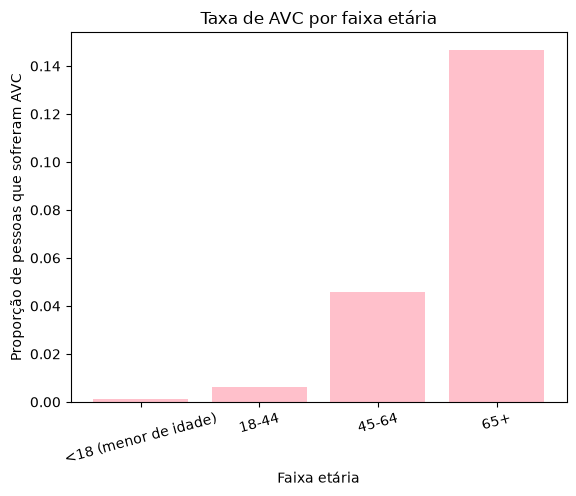

In [26]:
# grafico de barras: taxa de AVC por faixa etaria

plt.bar(df_tx_idade.index, df_tx_idade["stroke"], color="pink")
plt.title("Taxa de AVC por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Proporção de pessoas que sofreram AVC")
plt.xticks(rotation=15)
plt.show()

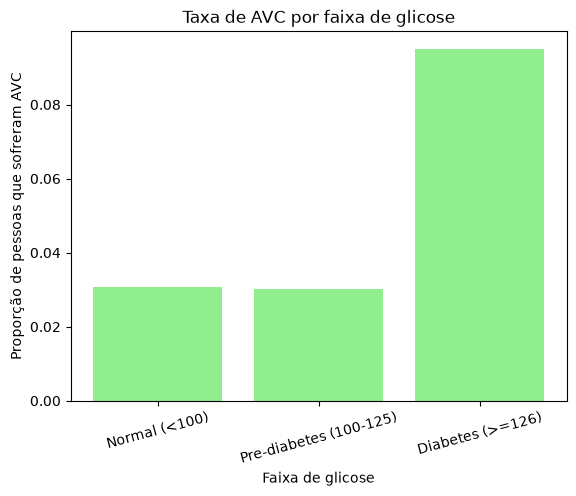

In [27]:
# grafico de barras: taxa de AVC por faixa de glicose

plt.bar(df_tx_glicose.index, df_tx_glicose["stroke"], color="lightgreen")
plt.title("Taxa de AVC por faixa de glicose")
plt.xlabel("Faixa de glicose")
plt.ylabel("Proporção de pessoas que sofreram AVC")
plt.xticks(rotation=15)
plt.show()